# Real estate price discovery 

Structured for review: **data → cleaning → features → modeling → evaluation → uncertainty → error analysis → outputs**.

| Section | Content |
|---------|---------|
| 1 | Setup & data loading |
| 2 | Cleaning & quality |
| 3 | EDA (optional context) |
| 4 | Train/val/test split & winsorization |
| 5 | Feature engineering |
| 6 | Modeling & champion selection |
| 7 | Baselines, intervals, `results_final`, labels |
| 8 | Error analysis, importance, SHAP |
| 9 | Intervals (quantile vs calibrated) |
| — | Appendix: product notes (optional) |

Take-home: **~200 Pune listings** — strong methods, modest data; avoid over-claiming tail coverage.


### Project overview

The goal of this assignment was to solve a real problem where similar properties are listed at very different prices, which reduces trust on the platform. Instead of treating this as just a prediction task, I approached it as a product problem. The idea was to build a system that can estimate a reasonable price range and help identify listings that look unusual, rather than trying to predict an exact price.

I started by focusing on the data, since the dataset is small (around 200 listings). I cleaned it by removing leakage columns, fixing area values (including parsing ranges), extracting BHK information from text, and standardizing categorical fields like location and builder names. I converted amenities into binary features and created an overall amenity score. From the description, I added simple signals like text length and a luxury keyword flag. I also applied a log transformation to price to handle skew. After exploring relationships such as area vs price and location effects, I built features using frequency encoding, target encoding, location tiers, and a few interaction terms.

For modeling, I tested Linear Regression, Ridge, Gradient Boosting, and CatBoost. Gradient Boosting performed best, giving around **21.5 RMSE and ~11 MAE on validation**, and about **~11–11.3 lakhs MAE on test with R² around 0.7**. This shows the model works well for typical properties, but still makes larger errors on high-price (luxury) listings.

Instead of returning just a single prediction, I designed the system to output a predicted price along with a calibrated range based on validation residuals (about **87% coverage**), a confidence signal, and a simple label such as fair, overpriced, or underpriced. The listed price is compared against this range to guide decisions. Normal cases can be approved, slightly unusual ones receive soft guidance, and extreme cases are routed for manual review instead of automatic action. When the model is uncertain, such as for wide ranges or luxury properties, automation is avoided completely.

This system is intended to be used in stages, starting with internal moderation, then seller guidance, and later limited user-facing signals. Overall, most of the improvement came from careful feature engineering and proper evaluation rather than complex models. The key takeaway is that combining prediction, uncertainty, and decision logic makes the solution practical and usable in a real product.

In [1]:
# Core imports, sklearn estimators, plotting defaults.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print('Ready — libraries imported and plot style set.')



Ready — libraries imported and plot style set.


In [2]:
# Load `Pune_Real_Estate_Data.xlsx` — shape, preview, dtypes, numeric describe.
from IPython.display import display

df = pd.read_excel('Pune_Real_Estate_Data.xlsx')
print('Shape:', df.shape)
display(df.head(5))
print(df.dtypes)
display(df.describe(include='all'))



Shape: (200, 18)


,Sr. No.,Location,Sub-Area,Propert Type,Property Area in Sq. Ft.,Price in lakhs,Price in Millions,Company Name,TownShip Name/ Society Name,Total TownShip Area in Acres,ClubHouse,School / University in Township,Hospital in TownShip,Mall in TownShip,Park / Jogging track,Swimming Pool,Gym,Description
0,1,"Pune, Maharashtra, India",Bavdhan,1 BHK,492,39,3.9,Shapoorji Paloonji,Vanaha,1000.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Shapoorji Paloonji comunity located in the sub...
1,2,"Pune, Maharashtra, India",Bavdhan,2 BHK,774,65,6.5,Shapoorji Paloonji,Vanaha,1000.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Vanaha Township located near the lonavala hill...
2,3,"Pune, Maharashtra, India",Bavdhan,3 BHK,889,74,7.4,Shapoorji Paloonji,Vanaha,1000.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Vanaha Society is suitable for all aged group ...
3,4,"Pune, Maharashtra, India",Bavdhan,3 BHK Grand,1018,89,8.9,Shapoorji Paloonji,Vanaha,1000.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Vanaha township are offering 3BHK grand prpoer...
4,5,"Pune, Maharashtra, India",Mahalunge,2BHK,743,74,7.4,Godrej Properties,Godrej Hills retreat,100.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,The area is a hub of prestigious schools like ...


Sr. No.                               int64
Location                             object
Sub-Area                             object
Propert Type                         object
Property Area in Sq. Ft.             object
Price in lakhs                       object
Price in Millions                   float64
Company Name                         object
TownShip Name/ Society Name          object
Total TownShip Area in Acres        float64
ClubHouse                            object
School / University in Township      object
Hospital in TownShip                 object
Mall in TownShip                     object
Park / Jogging track                 object
Swimming Pool                        object
Gym                                  object
Description                          object
dtype: object


,Sr. No.,Location,Sub-Area,Propert Type,Property Area in Sq. Ft.,Price in lakhs,Price in Millions,Company Name,TownShip Name/ Society Name,Total TownShip Area in Acres,ClubHouse,School / University in Township,Hospital in TownShip,Mall in TownShip,Park / Jogging track,Swimming Pool,Gym,Description
count,200.000000,200,200,200,200.0,200.0,199.000000,200,200,51.000000,200,200,200,200,200,200,200,200
unique,NaN,1,39,33,179.0,150.0,NaN,37,54,NaN,4,3,3,4,4,5,4,197
top,NaN,"Pune, Maharashtra, India",Kharadi,2bhk,670.0,65.0,NaN,Mantra Properties,Mantra 29 Gold,NaN,yes,no,no,no,yes,yes,yes,Welcome to your world; a world most only dream...
freq,NaN,200,16,56,4.0,5.0,NaN,29,13,NaN,97,140,133,78,141,75,103,2
mean,100.500000,NaN,NaN,NaN,NaN,NaN,9.525829,NaN,NaN,97.392157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,57.879185,NaN,NaN,NaN,NaN,NaN,10.186984,NaN,NaN,266.710786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,1.319000,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,50.750000,NaN,NaN,NaN,NaN,NaN,5.150000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,100.500000,NaN,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,150.250000,NaN,NaN,NaN,NaN,NaN,9.943500,NaN,NaN,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Missingness table: counts and % missing per column.
miss = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isna().sum().values,
    'pct_missing': (df.isna().mean().values * 100).round(2),
})
miss = miss.sort_values('missing_count', ascending=False).reset_index(drop=True)
display(miss)



,column,missing_count,pct_missing
0,Total TownShip Area in Acres,149,74.5
1,Price in Millions,1,0.5
2,ClubHouse,0,0.0
3,Gym,0,0.0
4,Swimming Pool,0,0.0
5,Park / Jogging track,0,0.0
6,Mall in TownShip,0,0.0
7,Hospital in TownShip,0,0.0
8,School / University in Township,0,0.0
9,Sr. No.,0,0.0


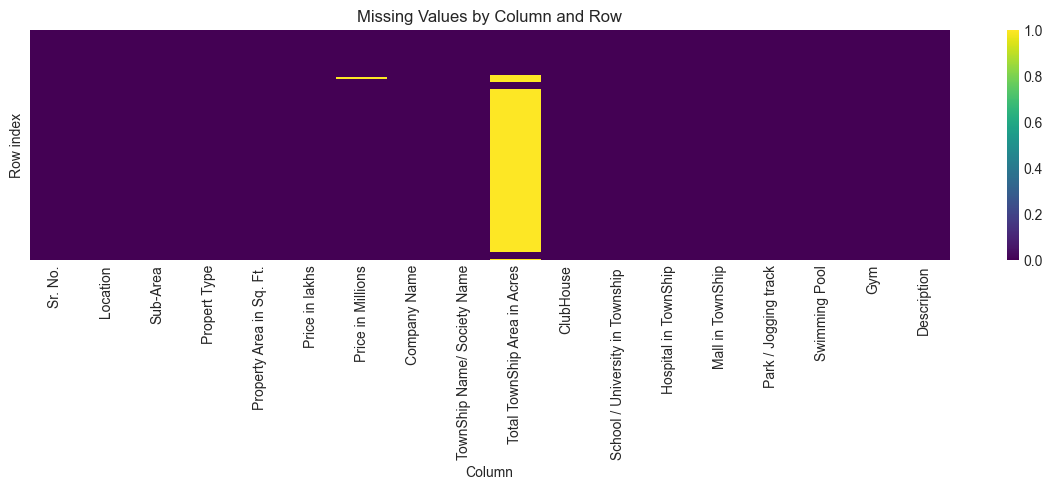

In [4]:
# Heatmap of missingness for visual scan.
plt.figure(figsize=(12, 5))
sns.heatmap(df.isna(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values by Column and Row')
plt.xlabel('Column')
plt.ylabel('Row index')
plt.tight_layout()
plt.show()



## 2. Data quality & cleaning

**Why:** model quality is bounded by leakage control, stable parses, and train-only statistics.


## Drop leakage and near-constant columns

`Price in Millions` is a **deterministic rescaling** of `Price in lakhs`—keeping it is pure **target leakage**. Record IDs and a constant city column carry no generalizable signal; they are removed so models do not waste capacity on spurious patterns.


In [5]:
# Drop IDs, constant geography, and `Price in Millions` (target leakage).
df = df.drop(columns=['Sr. No.', 'Location', 'Price in Millions'])
print('Step 1 complete: dropped Sr. No., Location, Price in Millions.')



Step 1 complete: dropped Sr. No., Location, Price in Millions.


## Invalid prices & area parsing

Prices are coerced numerically; non-positive values are dropped as data defects, not something to learn around.

`Property Area in Sq. Ft.` sometimes arrives as a **range string** (e.g. `"877 to 912"`). I collapse ranges to a single numeric sq.ft. so each row has one comparable size input.


In [6]:
# Numeric price; drop invalid rows; parse area range strings → single sq.ft. value.
import re


def parse_area_sqft(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float)) and not isinstance(x, bool):
        return float(x)
    s = str(x).lower().replace(',', ' ').replace('+', ' ')
    nums = re.findall(r'\d+(?:\.\d+)?', s)
    if not nums:
        return np.nan
    return float(np.mean([float(n) for n in nums]))


df['Price in lakhs'] = pd.to_numeric(df['Price in lakhs'], errors='coerce')
n_before = len(df)
df = df[(df['Price in lakhs'].notna()) & (df['Price in lakhs'] > 0)].reset_index(drop=True)
print('Rows dropped for invalid/non-positive price:', n_before - len(df))
df['Property Area in Sq. Ft.'] = df['Property Area in Sq. Ft.'].apply(parse_area_sqft)
df = df.dropna(subset=['Property Area in Sq. Ft.']).reset_index(drop=True)
print('Rows after Step 2 (price + area):', len(df))



Rows dropped for invalid/non-positive price: 1
Rows after Step 2 (price + area): 199


## `Sub-Area` normalization

Neighborhood strings are stripped and title-cased so the same pocket of the city does not split into artificial rare labels—important once frequency and target encodings are applied on a small train slice.


In [7]:
# Standardize `Sub-Area` strings; report unique count.
before = df['Sub-Area'].nunique()
df['Sub-Area'] = df['Sub-Area'].astype(str).str.strip().str.title()
after = df['Sub-Area'].nunique()
print('Unique Sub-Area before:', before)
print('Unique Sub-Area after:', after)



Unique Sub-Area before: 39
Unique Sub-Area after: 34


## `bhk_count` from property type

Bedrooms are extracted with regex from `Propert Type` (including half-BHK handling where applicable). This turns an unstructured label into a **numeric structural** feature trees and linear models can use consistently.


In [8]:
# Regex extract `bhk_count`; half-BHK handling; validate mapping sample.
import math
import re


def extract_bhk(raw):
    if pd.isna(raw):
        return np.nan
    s = str(raw).strip()
    if 'shop' in s.lower():
        return 0
    m = re.search(r'(\d+(?:\.\d+)?)', s)
    if m is None:
        return np.nan
    val = float(m.group(1))
    return int(math.ceil(val))


df['bhk_count'] = df['Propert Type'].apply(extract_bhk)
audit = df[['Propert Type', 'bhk_count']].drop_duplicates().sort_values('Propert Type')
print('Raw Propert Type → bhk_count (full audit table):')
print(audit.to_string(index=False))
df = df.drop(columns=['Propert Type'])



Raw Propert Type → bhk_count (full audit table):
Propert Type  bhk_count
       1 BHK          1
       1 bhk          1
        1BHK          1
        1bhk          1
       1bhk           1
       2 BHK          2
       2 bhk          2
      2 bhk           2
     2+2 bhk          2
     2.5 BHK          3
     2.5 bhk          3
        2BHK          2
        2bhk          2
       2bhk           2
     3  bhk           3
       3 BHK          3
      3 BHK           3
 3 BHK Grand          3
       3 bhk          3
     3+2bhk           3
     3.5 bhk          4
      3.5bhk          4
        3BHK          3
        3bhk          3
       3bhk           3
       4 bhk          4
      4.5bhk          5
        4BHK          4
        4bhk          4
       5 bhk          5
        5BHK          5
        6BHK          6
        shop          0


## Township acreage imputation

`Total TownShip Area in Acres` has missing values. I impute with the **median** and keep the field as a weak **project-scale** signal; unit-level area remains the primary size driver.


In [9]:
# Impute `Total TownShip Area in Acres` with median.
med_acres = df['Total TownShip Area in Acres'].median()
df['Total TownShip Area in Acres'] = df['Total TownShip Area in Acres'].fillna(med_acres)
print('Median acres used for imputation:', med_acres)



Median acres used for imputation: 25.0


## Binary amenities → {0, 1}

Amenity fields may appear as yes/no, 0/1, or minor variants. They are normalized to **integers** so sums, rates, and tree splits see a consistent encoding.


In [10]:
# Amenities → {0,1}; handles pre-encoded numerics and yes/no strings.
# Raw 0/1 + .astype(str) gives '0'/'1', which must not be turned into NaN by a yes/no-only map.
binary_cols = [
    'ClubHouse',
    'School / University in Township ',
    'Hospital in TownShip',
    'Mall in TownShip',
    'Park / Jogging track',
    'Swimming Pool',
    'Gym',
]
_STR_MAP = {'yes': 1, 'no': 0, 'y': 1, 'n': 0, '1': 1, '0': 0, 'true': 1, 'false': 0}


def amenity_to_01(col: pd.Series) -> pd.Series:
    num = pd.to_numeric(col, errors='coerce')
    out = pd.Series(np.nan, index=col.index, dtype=float)
    ok = num.notna() & num.isin([0, 1])
    out.loc[ok] = num.loc[ok]
    rest = ~ok
    if rest.any():
        t = col.loc[rest].astype(str).str.strip().str.lower()
        out.loc[rest] = t.map(_STR_MAP).astype(float)
    # Unknown / missing → 0 (treat as absent)
    return out.fillna(0).astype(int)


print('ClubHouse before:')
print(df['ClubHouse'].value_counts(dropna=False))
for c in binary_cols:
    df[c] = amenity_to_01(df[c])
print('ClubHouse after:')
print(df['ClubHouse'].value_counts(dropna=False))



ClubHouse before:
ClubHouse
yes    97
Yes    50
no     49
no      3
Name: count, dtype: int64
ClubHouse after:
ClubHouse
1    147
0     52
Name: count, dtype: int64


## `amenity_score`

The count of the seven amenities (0–7) is a compact **bundle** feature: buyers price **packages**, not seven independent toggles. It stays interpretable for product copy (“higher amenity bundle”).


In [11]:
# `amenity_score` = sum of seven amenity flags.
df['amenity_score'] = df[binary_cols].sum(axis=1)
print(df['amenity_score'].value_counts().sort_index())



amenity_score
1    21
2    29
3    46
4    97
7     6
Name: count, dtype: int64


## Builder & township strings

`Company Name` and `TownShip Name/ Society Name` are title-cased to collapse obvious duplicates before frequency and target encoding—noisy labels would distort category statistics.


In [12]:
# Title-case builder & township names.
df['Company Name'] = df['Company Name'].astype(str).str.strip().str.title()
df['TownShip Name/ Society Name'] = df['TownShip Name/ Society Name'].astype(str).str.strip().str.title()
print('Step 8 complete: company and township title-cased.')



Step 8 complete: company and township title-cased.


## Description-derived features

Free text carries soft positioning cues. I use **length** and a small **luxury keyword** flag—enough signal for this sample size without committing to a full NLP pipeline.


In [13]:
# `desc_length`, `desc_luxury_flag`; drop raw description.
lux_keywords = ('luxury', 'premium', 'grand', 'elite', 'exclusive')
df['desc_length'] = df['Description'].astype(str).str.len()


def luxury_flag(text):
    t = str(text).lower()
    return int(any(k in t for k in lux_keywords))


df['desc_luxury_flag'] = df['Description'].apply(luxury_flag)
df = df.drop(columns=['Description'])
print('Step 9 complete: desc_length, desc_luxury_flag; Description dropped.')



Step 9 complete: desc_length, desc_luxury_flag; Description dropped.


## Log target

Raw prices are highly skewed; **`log1p`** stabilizes variance for regression and aligns with roughly **multiplicative** price effects. All **business-facing MAE/RMSE** in the modeling section are reported back on the **Lakhs** scale via `expm1`.

**Reference skewness** (from cleaning cell): raw ~6.0 → log ~0.86.


In [14]:
# `log_price = log1p(price)`; skewness check; row count after cleaning.
df['log_price'] = np.log1p(df['Price in lakhs'])
print('Skewness Price in lakhs:', round(df['Price in lakhs'].skew(), 2))
print('Skewness log_price:', round(df['log_price'].skew(), 2))
print('Final shape:', df.shape)
display(df.head())



Skewness Price in lakhs: 6.0
Skewness log_price: 0.86
Final shape: (199, 18)


,Sub-Area,Property Area in Sq. Ft.,Price in lakhs,Company Name,TownShip Name/ Society Name,Total TownShip Area in Acres,ClubHouse,School / University in Township,Hospital in TownShip,Mall in TownShip,Park / Jogging track,Swimming Pool,Gym,bhk_count,amenity_score,desc_length,desc_luxury_flag,log_price
0,Bavdhan,492.0,39.0,Shapoorji Paloonji,Vanaha,1000.0,1,1,1,1,1,1,1,1,7,273,0,3.688879
1,Bavdhan,774.0,65.0,Shapoorji Paloonji,Vanaha,1000.0,1,1,1,1,1,1,1,2,7,179,0,4.189655
2,Bavdhan,889.0,74.0,Shapoorji Paloonji,Vanaha,1000.0,1,1,1,1,1,1,1,3,7,212,0,4.317488
3,Bavdhan,1018.0,89.0,Shapoorji Paloonji,Vanaha,1000.0,1,1,1,1,1,1,1,3,7,186,1,4.499810
4,Mahalunge,743.0,74.0,Godrej Properties,Godrej Hills Retreat,100.0,1,1,1,1,1,1,1,2,7,223,0,4.317488


# 3. Exploratory analysis (market shape)


### Price distribution — raw vs log

Confirms heavy right tail and justifies the log target.


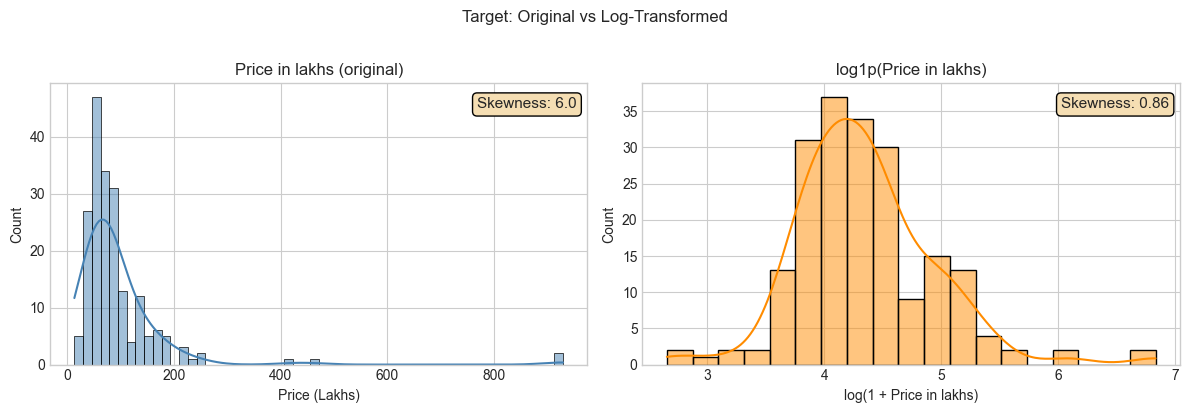

In [15]:
# Histogram/KDE: price and log_price.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Price in lakhs'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Price in lakhs (original)')
axes[0].set_xlabel('Price (Lakhs)')
axes[0].set_ylabel('Count')
axes[0].text(0.98, 0.95, 'Skewness: 6.0', transform=axes[0].transAxes, ha='right', va='top', fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat'))

sns.histplot(df['log_price'], kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('log1p(Price in lakhs)')
axes[1].set_xlabel('log(1 + Price in lakhs)')
axes[1].set_ylabel('Count')
axes[1].text(0.98, 0.95, 'Skewness: 0.86', transform=axes[1].transAxes, ha='right', va='top', fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat'))

plt.suptitle('Target: Original vs Log-Transformed', y=1.02)
plt.tight_layout()
plt.show()



### Price by BHK

Shows segmentation by unit configuration; informs interaction terms later.


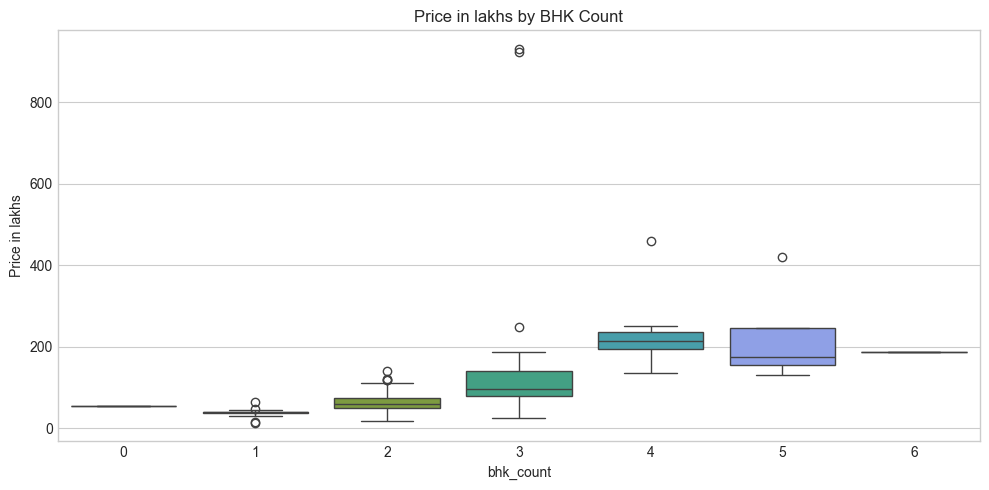

In [16]:
# Boxplot: price by sorted `bhk_count`.
order = sorted(df['bhk_count'].unique())
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='bhk_count', y='Price in lakhs', order=order, palette='husl')
plt.title('Price in lakhs by BHK Count')
plt.xlabel('bhk_count')
plt.ylabel('Price in lakhs')
plt.tight_layout()
plt.show()



### Area vs price

Validates size–price relationship and multi-BHK coloring.


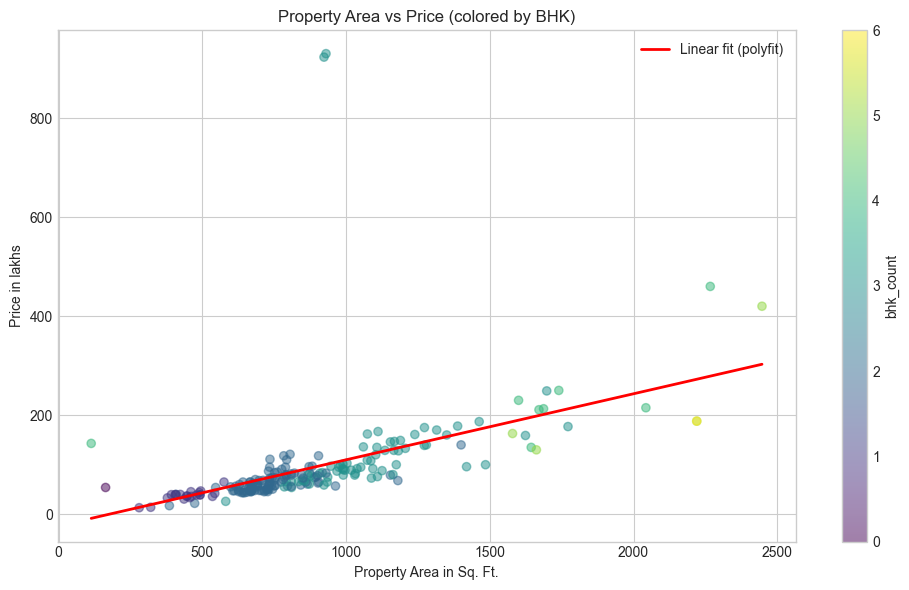

In [17]:
# Scatter: area vs price colored by BHK; polyfit overlay.
plt.figure(figsize=(10, 6))
sc = plt.scatter(df['Property Area in Sq. Ft.'], df['Price in lakhs'], c=df['bhk_count'], cmap='viridis', alpha=0.5)
plt.colorbar(sc, label='bhk_count')
xa = df['Property Area in Sq. Ft.'].values
ya = df['Price in lakhs'].values
z = np.polyfit(xa, ya, 1)
p = np.poly1d(z)
x_line = np.linspace(xa.min(), xa.max(), 100)
plt.plot(x_line, p(x_line), color='red', linewidth=2, label='Linear fit (polyfit)')
plt.legend()
plt.title('Property Area vs Price (colored by BHK)')
plt.xlabel('Property Area in Sq. Ft.')
plt.ylabel('Price in lakhs')
plt.tight_layout()
plt.show()



### Median price by `Sub-Area`

Geographic level shifts; motivates location priors and tiers.


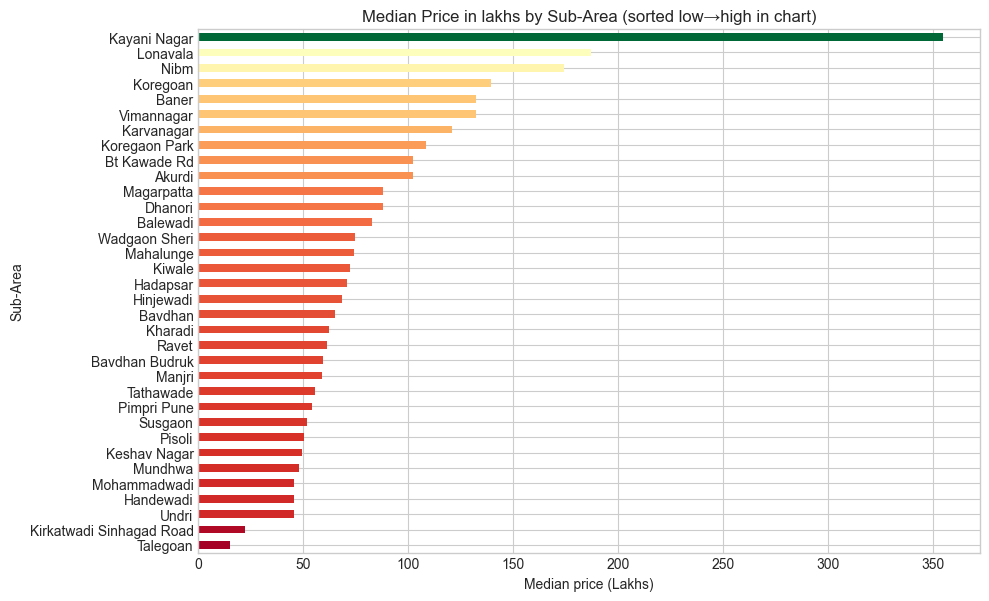

In [18]:
# Median Lakhs by Sub-Area (horizontal bars).
med_area = df.groupby('Sub-Area')['Price in lakhs'].median().sort_values(ascending=True)
norm = (med_area - med_area.min()) / (med_area.max() - med_area.min() + 1e-9)
colors = plt.cm.RdYlGn(norm)
plt.figure(figsize=(10, max(5, len(med_area) * 0.18)))
med_area.plot(kind='barh', color=colors)
plt.title('Median Price in lakhs by Sub-Area (sorted low→high in chart)')
plt.xlabel('Median price (Lakhs)')
plt.ylabel('Sub-Area')
plt.tight_layout()
plt.show()



### Numeric correlation heatmap

Surfaces multicollinearity risks for linear models; trees handle overlap differently.


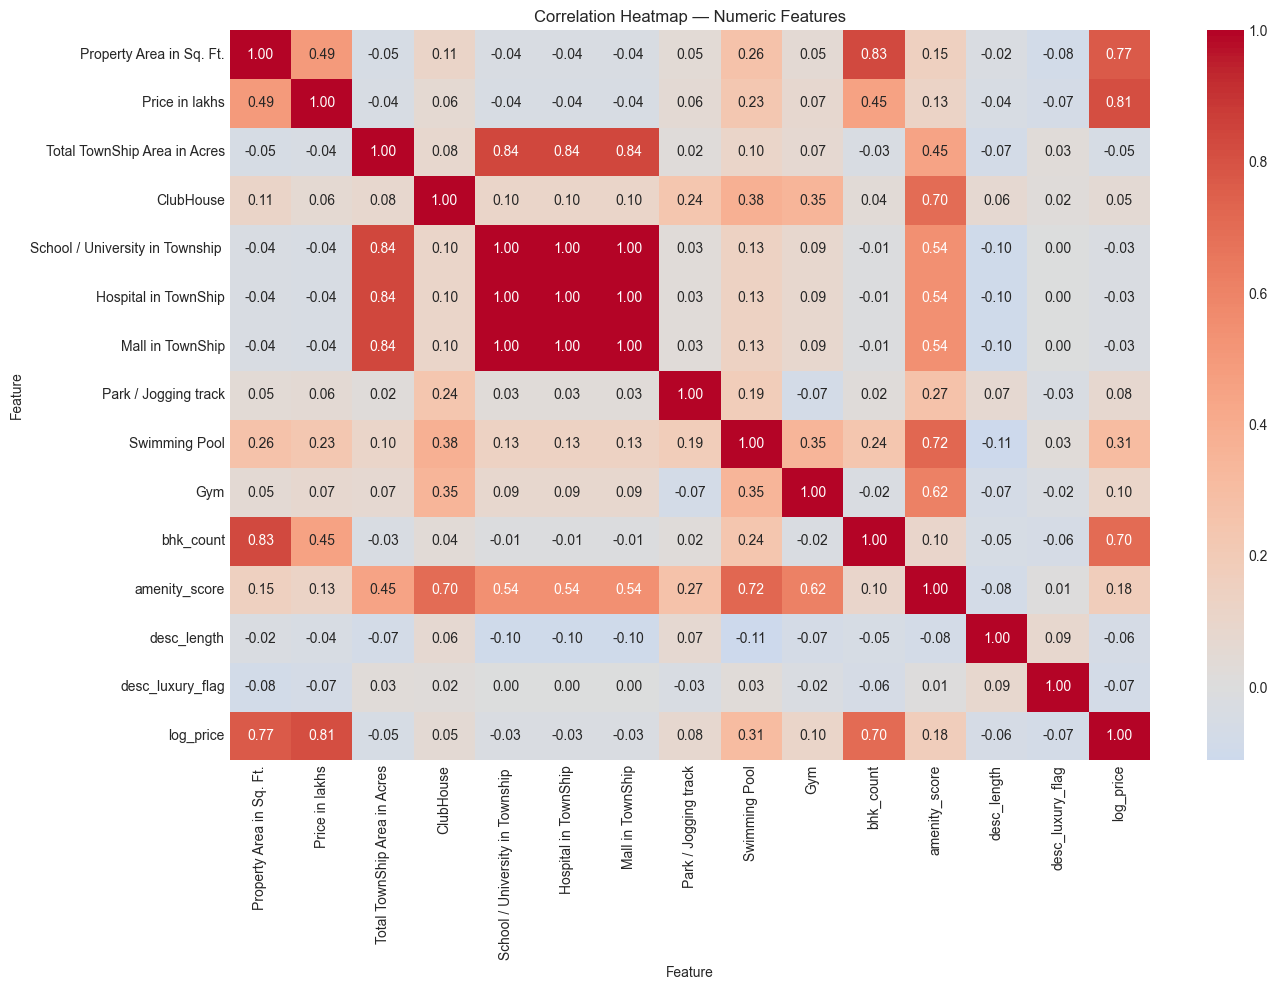

In [19]:
# Pearson correlation heatmap on numeric columns.
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=False)
plt.title('Correlation Heatmap — Numeric Features')
plt.xlabel('Feature')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



### Amenity prevalence

Shares how common each amenity is—sparse flags can be noisy at small n.


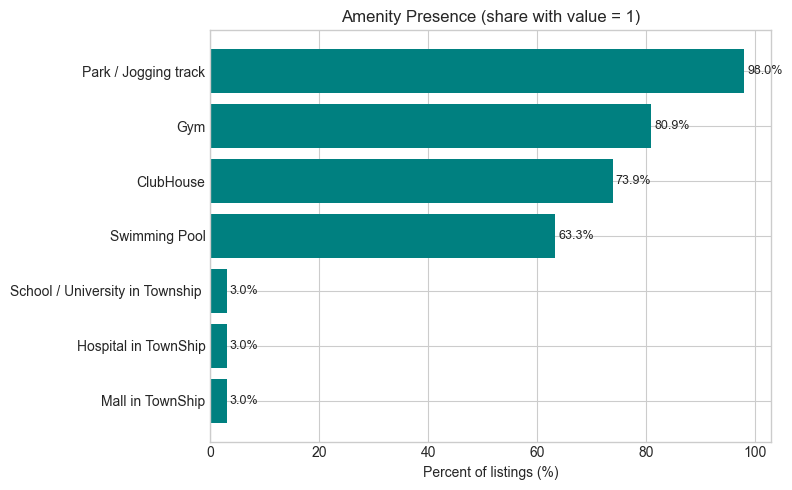

In [20]:
# Amenity take-up rates (%, horizontal bars).
pcts = [(c, df[c].mean() * 100) for c in binary_cols]
pcts.sort(key=lambda x: x[1], reverse=True)
labels, vals = zip(*pcts)
plt.figure(figsize=(8, 5))
bars = plt.barh(range(len(labels)), vals, color='teal')
plt.yticks(range(len(labels)), labels)
plt.xlabel('Percent of listings (%)')
plt.title('Amenity Presence (share with value = 1)')
for i, b in enumerate(bars):
    plt.text(b.get_width() + 0.5, b.get_y() + b.get_height() / 2, f'{vals[i]:.1f}%', va='center', fontsize=9)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



### Price vs amenity score

Tests whether the bundle score segments price as expected.


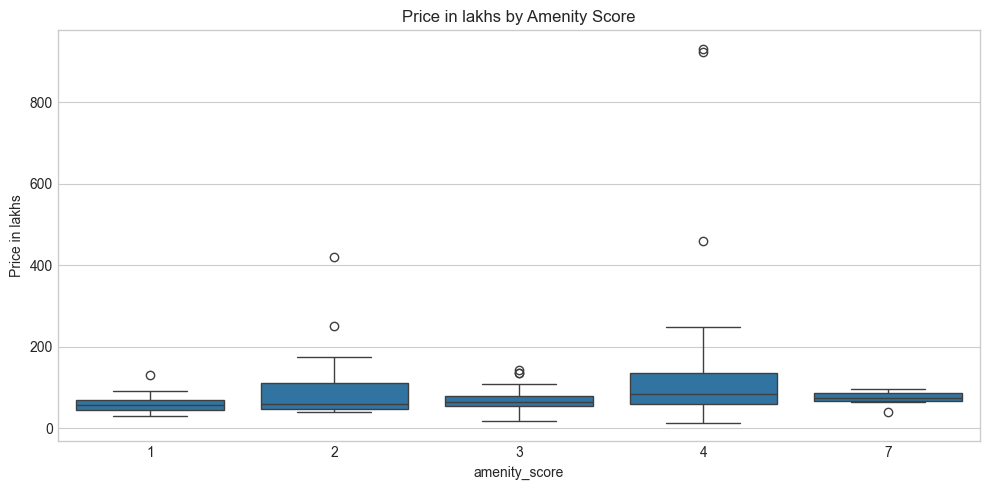

In [21]:
# Boxplot: price vs `amenity_score`.
plt.figure(figsize=(10, 5))
order = sorted(df['amenity_score'].unique())
sns.boxplot(data=df, x='amenity_score', y='Price in lakhs', order=order)
plt.title('Price in lakhs by Amenity Score')
plt.xlabel('amenity_score')
plt.ylabel('Price in lakhs')
plt.tight_layout()
plt.show()



### Median price by developer (top 15)

Shows brand / project effects that motivate company-level encoding.


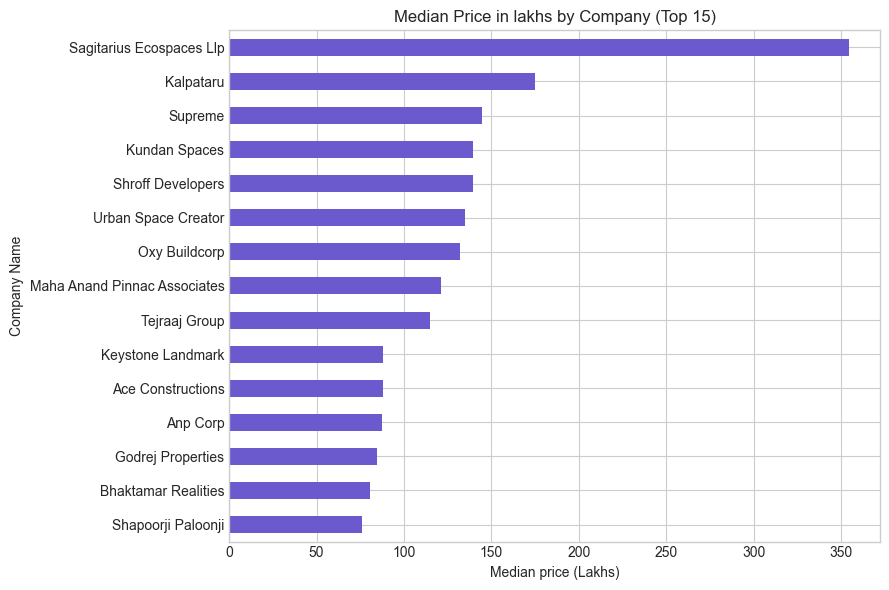

In [22]:
# Top 15 companies by median price (horizontal bars).
co = df.groupby('Company Name')['Price in lakhs'].median().sort_values(ascending=False).head(15)
co = co.sort_values(ascending=True)
plt.figure(figsize=(9, 6))
co.plot(kind='barh', color='slateblue')
plt.title('Median Price in lakhs by Company (Top 15)')
plt.xlabel('Median price (Lakhs)')
plt.ylabel('Company Name')
plt.tight_layout()
plt.show()



## 4. Experimental design — split & winsorization

**Why:** stratify on price so validation/test see tail behavior; winsor caps from **train only** limit RMSE leverage without val leakage.


## Winsorization — implementation note

Caps = train quantiles; `log_price` refreshed after capping. This is leakage-safe and reduces tail leverage without dropping entire luxury rows unless policy requires it.


In [23]:
# Stratified 70/15/15 indices; train-quantile winsorize `Price in lakhs`; refresh `log_price`.
np.random.seed(42)
n = len(df)
row_idx = np.arange(n)
price_bins_all = pd.qcut(df['log_price'], q=4, labels=False, duplicates='drop')
bvals = price_bins_all.to_numpy() if hasattr(price_bins_all, 'to_numpy') else np.array(price_bins_all)

train_val_idx, test_idx = train_test_split(
    row_idx, test_size=0.15, random_state=42, stratify=bvals
)
rel_bins = bvals[train_val_idx]
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.15 / 0.85,
    random_state=42,
    stratify=rel_bins,
)

price_train = df.iloc[train_idx]['Price in lakhs']
low_cap = price_train.quantile(0.01)
high_cap = price_train.quantile(0.99)
print('Winsor caps from train (1st–99th pct, Lakhs):', round(float(low_cap), 2), '–', round(float(high_cap), 2))

df['Price in lakhs'] = df['Price in lakhs'].clip(lower=low_cap, upper=high_cap)
df['log_price'] = np.log1p(df['Price in lakhs'])

print('Train / Val / Test sizes:', len(train_idx), len(val_idx), len(test_idx))



Winsor caps from train (1st–99th pct, Lakhs): 20.6 – 241.78
Train / Val / Test sizes: 139 30 30


## 5. Feature engineering

**Why:** ~200 rows won’t support wide one-hots; dense encodings carry **location / builder** signal without exploding dimensionality.


In [24]:
# Train-only encodings + engineered columns; build X/y, CatBoost cat index.


def frequency_encoding(series: pd.Series, train_ix: np.ndarray) -> pd.Series:
    vc = series.iloc[train_ix].value_counts(normalize=True)
    return series.map(vc).fillna(0.0)


def target_encode(series: pd.Series, y_log: pd.Series, train_ix: np.ndarray, smoothing: float = 10.0) -> pd.Series:
    y_tr = y_log.iloc[train_ix]
    mean_all = float(y_tr.mean())
    g = y_tr.groupby(series.iloc[train_ix])
    cnt = g.count()
    m = g.mean()
    smoothed = (cnt * m + smoothing * mean_all) / (cnt + smoothing)
    return series.map(smoothed).fillna(mean_all)


def location_tier_col(df_in: pd.DataFrame, train_ix: np.ndarray, price_col: str = 'Price in lakhs') -> pd.Series:
    med_by_area = df_in.iloc[train_ix].groupby('Sub-Area')[price_col].median()
    q1, q2 = med_by_area.quantile([1 / 3, 2 / 3])

    def tier_for_median(m):
        if m <= q1:
            return 'budget'
        if m <= q2:
            return 'mid'
        return 'premium'

    mapping = {k: tier_for_median(v) for k, v in med_by_area.items()}

    def row_tier(row):
        return mapping.get(row['Sub-Area'], 'mid')

    return df_in.apply(row_tier, axis=1)


def train_median_ppsf(df_in: pd.DataFrame, train_ix: np.ndarray):
    t = df_in.iloc[train_ix].copy()
    t['ppsf'] = t['Price in lakhs'] / t['Property Area in Sq. Ft.'].replace(0, np.nan)
    by_sub = t.groupby('Sub-Area')['ppsf'].median()
    overall = float(t['ppsf'].median())
    return by_sub, overall


def add_engineered_features(df_in: pd.DataFrame, train_ix: np.ndarray, y_log: pd.Series) -> pd.DataFrame:
    out = df_in.copy()
    ppsf_map, ppsf_glob = train_median_ppsf(out, train_ix)
    out['train_median_ppsf_subarea'] = out['Sub-Area'].map(ppsf_map).fillna(ppsf_glob)

    out['freq_subarea'] = frequency_encoding(out['Sub-Area'], train_ix)
    out['freq_company'] = frequency_encoding(out['Company Name'], train_ix)
    out['freq_township'] = frequency_encoding(out['TownShip Name/ Society Name'], train_ix)

    out['te_subarea'] = target_encode(out['Sub-Area'], y_log, train_ix)
    out['te_company'] = target_encode(out['Company Name'], y_log, train_ix)
    out['te_township'] = target_encode(out['TownShip Name/ Society Name'], y_log, train_ix)

    out['location_tier'] = location_tier_col(out, train_ix)
    out['location_tier_code'] = out['location_tier'].map({'budget': 0, 'mid': 1, 'premium': 2})

    out['log_area'] = np.log1p(out['Property Area in Sq. Ft.'])
    out['area_x_bhk'] = out['Property Area in Sq. Ft.'] * out['bhk_count']
    out['amenity_x_area'] = out['amenity_score'] * out['Property Area in Sq. Ft.']
    return out


base_cols = [
    'Property Area in Sq. Ft.',
    'Total TownShip Area in Acres',
    'bhk_count',
    'amenity_score',
    'desc_length',
    'desc_luxury_flag',
    'ClubHouse',
    'School / University in Township ',
    'Hospital in TownShip',
    'Mall in TownShip',
    'Park / Jogging track',
    'Swimming Pool',
    'Gym',
    'Sub-Area',
    'Company Name',
    'TownShip Name/ Society Name',
    'Price in lakhs',
    'log_price',
]

df_model = df[base_cols].copy()
y_log_full = df_model['log_price']

df_feat = add_engineered_features(df_model, train_idx, y_log_full)

numeric_features = [
    'Property Area in Sq. Ft.',
    'log_area',
    'Total TownShip Area in Acres',
    'bhk_count',
    'amenity_score',
    'desc_length',
    'desc_luxury_flag',
    'ClubHouse',
    'School / University in Township ',
    'Hospital in TownShip',
    'Mall in TownShip',
    'Park / Jogging track',
    'Swimming Pool',
    'Gym',
    'train_median_ppsf_subarea',
    'freq_subarea',
    'freq_company',
    'freq_township',
    'te_subarea',
    'te_company',
    'te_township',
    'location_tier_code',
    'area_x_bhk',
    'amenity_x_area',
]

cat_names = ['Sub-Area', 'Company Name', 'TownShip Name/ Society Name', 'location_tier']

X_all = pd.concat([df_feat[numeric_features], df_feat[cat_names]], axis=1)
y_all = df_feat['log_price']

X_train = X_all.iloc[train_idx]
X_val = X_all.iloc[val_idx]
X_test = X_all.iloc[test_idx]
y_train = y_all.iloc[train_idx]
y_val = y_all.iloc[val_idx]
y_test = y_all.iloc[test_idx]

cat_idx = [X_train.columns.get_loc(c) for c in cat_names]
print('Feature matrix (train):', X_train.shape)



Feature matrix (train): (139, 28)


## 6b. Ablation: where the lift comes from

To isolate **features** (not a new tuning contest), each row fits the same **Ridge** pipeline on `train` and scores `validation` in **Lakhs**. The naive baseline is the **train-mean** predictor in log space.

The **model comparison** in the next section then selects **family + hyperparameters** on the **full** matrix (GB, CatBoost, etc.). That separation keeps the story honest: most gains here are **leakage-safe structure + encodings**, not an ad hoc algorithm change.

Interpretation guide: drops in RMSE/MAE as blocks stack mean those signals carry **marginal validation lift** at this sample size.


In [25]:
# Ablation: staged feature blocks with a fixed Ridge estimator (isolates feature lift).
from IPython.display import display
from sklearn.linear_model import Ridge

def _m_lv(y_true_log, y_pred_log):
    yt = np.expm1(np.asarray(y_true_log).ravel())
    yp = np.expm1(np.asarray(y_pred_log).ravel())
    return (
        float(np.sqrt(mean_squared_error(yt, yp))),
        float(mean_absolute_error(yt, yp)),
    )

s1 = ('1 Naive mean (log)', None)
s2 = ('2 Core numeric', [
    'Property Area in Sq. Ft.', 'log_area', 'Total TownShip Area in Acres',
    'bhk_count', 'amenity_score', 'desc_length', 'desc_luxury_flag',
    'ClubHouse', 'School / University in Township ', 'Hospital in TownShip',
    'Mall in TownShip', 'Park / Jogging track', 'Swimming Pool', 'Gym',
])
s3 = ('3 + Location priors', s2[1] + ['train_median_ppsf_subarea', 'location_tier_code'])
s4 = ('4 + Frequency enc.', s3[1] + ['freq_subarea', 'freq_company', 'freq_township'])
s5 = ('5 + Target enc.', s4[1] + ['te_subarea', 'te_company', 'te_township'])
s6 = ('6 Full numeric block', numeric_features)
_ab = [s1, s2, s3, s4, s5, s6]
_rows = []
for label, cols in _ab:
    if cols is None:
        pred = np.full(shape=len(y_val), fill_value=y_train.mean())
        rmse, mae = _m_lv(y_val, pred)
        note = 'Train-mean in log space'
    else:
        rpipe = Pipeline([('scaler', StandardScaler()), ('m', Ridge(alpha=5.0))])
        rpipe.fit(X_train[cols], y_train)
        rmse, mae = _m_lv(y_val, rpipe.predict(X_val[cols]))
        note = '%d cols' % len(cols)
    _rows.append({'Stage': label, 'Val RMSE': round(rmse, 2), 'Val MAE': round(mae, 2), 'Note': note})
display(pd.DataFrame(_rows))
print('Champion tuned models on the full design matrix are in the next cells; they can beat Ridge once non-linearities matter.')



,Stage,Val RMSE,Val MAE,Note
0,1 Naive mean (log),58.68,40.44,Train-mean in log space
1,2 Core numeric,40.62,22.94,14 cols
2,3 + Location priors,33.16,16.16,16 cols
3,4 + Frequency enc.,32.88,15.81,19 cols
4,5 + Target enc.,27.52,12.85,22 cols
5,6 Full numeric block,26.28,11.50,24 cols


Champion tuned models on the full design matrix are in the next cells; they can beat Ridge once non-linearities matter.


## 6. Modeling (linear → ridge → GB → CatBoost)

**Why:** multiple inductive biases — sanity checks (linear), correlated numeric (ridge), nonlinear interactions (trees).


In [26]:
# Tune Linear, Ridge, sklearn GB, CatBoost; validation metrics in Lakhs.
from catboost import CatBoostRegressor
from IPython.display import display
from sklearn.model_selection import KFold

Xn_train = X_train[numeric_features]
Xn_val = X_val[numeric_features]


def metrics_lakhs(y_true_log, y_pred_log):
    yt = np.expm1(np.asarray(y_true_log).ravel())
    yp = np.expm1(np.asarray(y_pred_log).ravel())
    rmse = float(np.sqrt(mean_squared_error(yt, yp)))
    mae = float(mean_absolute_error(yt, yp))
    r2 = float(r2_score(yt, yp))
    return rmse, mae, r2


lin_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])
lin_pipe.fit(Xn_train, y_train)
lin_v = metrics_lakhs(y_val, lin_pipe.predict(Xn_val))
print(f'LinearRegression | Val RMSE={lin_v[0]:.1f} MAE={lin_v[1]:.1f} R²={lin_v[2]:.3f}')

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge()),
])
ridge_gs = GridSearchCV(
    ridge_pipe,
    {'model__alpha': np.logspace(-3, 3, 13)},
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)
ridge_gs.fit(Xn_train, y_train)
ridge_best = ridge_gs.best_estimator_
rv = metrics_lakhs(y_val, ridge_best.predict(Xn_val))
print(f'Ridge (α={ridge_gs.best_params_["model__alpha"]:.4f}) | Val RMSE={rv[0]:.1f} MAE={rv[1]:.1f} R²={rv[2]:.3f}')

gb = GradientBoostingRegressor(random_state=42)
gb_gs = GridSearchCV(
    gb,
    {
        'n_estimators': [100, 200],
        'max_depth': [2, 3, 4],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8, 1.0],
    },
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)
gb_gs.fit(Xn_train, y_train)
gb_best = gb_gs.best_estimator_
gv = metrics_lakhs(y_val, gb_best.predict(Xn_val))
print('GB', gb_gs.best_params_, '| Val RMSE=%.1f' % gv[0])

cb_params = []
for depth in [4, 6]:
    for lr in [0.03, 0.1]:
        for it in [200, 400]:
            for l2 in [3, 9]:
                cb_params.append({'depth': depth, 'learning_rate': lr, 'iterations': it, 'l2_leaf_reg': l2})

kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_cb, best_s = None, np.inf
for p in cb_params:
    fold_rmse = []
    for tr_loc, ho_loc in kf.split(np.arange(len(X_train))):
        cb = CatBoostRegressor(
            random_seed=42, verbose=False, loss_function='RMSE',
            allow_writing_files=False, depth=p['depth'], learning_rate=p['learning_rate'],
            iterations=p['iterations'], l2_leaf_reg=p['l2_leaf_reg'],
        )
        cb.fit(
            X_train.iloc[tr_loc], y_train.iloc[tr_loc],
            cat_features=cat_idx, verbose=False,
        )
        pred = cb.predict(X_train.iloc[ho_loc])
        fold_rmse.append(np.sqrt(mean_squared_error(y_train.iloc[ho_loc], pred)))
    m = float(np.mean(fold_rmse))
    if m < best_s:
        best_s, best_cb = m, p
print('CatBoost best CV grid:', best_cb, 'CV RMSE (log scale):', round(best_s, 4))

cb_best = CatBoostRegressor(
    random_seed=42, verbose=False, allow_writing_files=False, **best_cb
)
cb_best.fit(X_train, y_train, cat_features=cat_idx)
cv = metrics_lakhs(y_val, cb_best.predict(X_val))
print(f'CatBoost | Val RMSE={cv[0]:.1f} MAE={cv[1]:.1f} R²={cv[2]:.3f}')

results_val = pd.DataFrame([
    ['LinearRegression', lin_v[0], lin_v[1], lin_v[2]],
    ['Ridge', rv[0], rv[1], rv[2]],
    ['GradientBoosting', gv[0], gv[1], gv[2]],
    ['CatBoost', cv[0], cv[1], cv[2]],
], columns=['Model', 'Val RMSE (Lakhs)', 'Val MAE (Lakhs)', 'Val R²'])
display(results_val.round(3))



LinearRegression | Val RMSE=27.5 MAE=11.7 R²=0.771


Ridge (α=3.1623) | Val RMSE=26.5 MAE=11.3 R²=0.786


GB {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'subsample': 1.0} | Val RMSE=21.5


CatBoost best CV grid: {'depth': 4, 'learning_rate': 0.03, 'iterations': 400, 'l2_leaf_reg': 3} CV RMSE (log scale): 0.1651
CatBoost | Val RMSE=22.0 MAE=11.7 R²=0.853


,Model,Val RMSE (Lakhs),Val MAE (Lakhs),Val R²
0,LinearRegression,27.454,11.684,0.771
1,Ridge,26.546,11.288,0.786
2,GradientBoosting,21.528,11.044,0.859
3,CatBoost,21.960,11.700,0.853


## 6b. Champion selection & locked test

Refit on **train ∪ val** once; score **test** a single time. **Baselines** and **calibrated intervals** use train-only fitting for the calibration model.


Champion: GradientBoosting



=== Final TEST (15% holdout) — one readout ===
RMSE=27.64 Lakhs | MAE=11.27 | R²=0.709
RMSE − MAE = 16.37 Lakhs

=== Baselines vs champion (test, Lakhs) ===


,Model,Test RMSE,Test MAE,Test R²
0,Train-mean (Lakhs),51.263,36.806,-0.001
1,PPSF × area (train medians by Sub-Area),35.403,12.978,0.523
2,Champion: GradientBoosting,27.643,11.271,0.709



=== Interval coverage & calibration (test) ===
Primary [q5,q95] residual bands — empirical coverage: 86.7% (nominal central: 90%)
→ Near nominal — reasonable at n_test≈30.
Symmetric ±1.96σ bands — empirical coverage: 96.7% (Gaussian reference ≈ 95%)

Coverage by actual-price tier (low / mid / high):


,coverage_%
actual_price,
low,100.0
mid,90.0
high,70.0



% Overpriced (actual > upper bound): 6.7%

=== results_final (worst |error| first) ===


,Actual Price,Predicted Price,Lower Bound,Upper Bound,Error,Abs Error,Price Label
0,241.78,99.55,84.85,122.96,142.23,142.23,Overpriced
1,136.00,103.66,88.97,127.08,32.34,32.34,Overpriced
2,241.78,221.95,207.26,245.37,19.83,19.83,Fair
3,98.87,117.00,102.31,140.41,-18.13,18.13,Underpriced
4,65.00,79.69,65.00,103.11,-14.69,14.69,Underpriced
5,121.00,108.73,94.03,132.14,12.27,12.27,Fair
6,75.00,85.22,70.53,108.64,-10.22,10.22,Fair
7,118.00,109.73,95.04,133.14,8.27,8.27,Fair
8,109.00,101.32,86.63,124.73,7.68,7.68,Fair
9,59.00,66.16,51.46,89.57,-7.16,7.16,Fair


Price label counts (test):


Fair           26
Overpriced      2
Underpriced     2
Name: count, dtype: int64

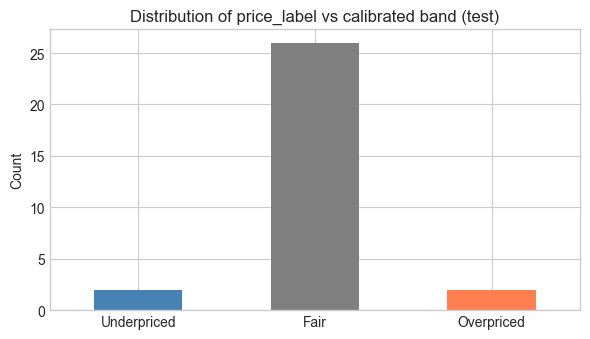

predict_with_interval demo: (66.15790087108664, 51.46454930414542, 89.57291727757843, 'Fair')


In [27]:
# Refit champion on train∪val; test evaluation; baselines; calibrated prediction intervals.
# Baselines use ONLY train statistics (no peeking at val/test targets beyond indices).
from IPython.display import display

best_name = results_val.loc[results_val['Val RMSE (Lakhs)'].idxmin(), 'Model']
print('Champion:', best_name)

X_trv = pd.concat([X_train, X_val])
y_trv = pd.concat([y_train, y_val])
Xn_trv = X_trv[numeric_features]

if best_name == 'LinearRegression':
    final_model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression()),
    ])
    final_model.fit(Xn_trv, y_trv)
    test_pred_log = final_model.predict(X_test[numeric_features])
elif best_name == 'Ridge':
    final_model = clone(ridge_gs.best_estimator_)
    final_model.fit(Xn_trv, y_trv)
    test_pred_log = final_model.predict(X_test[numeric_features])
elif best_name == 'GradientBoosting':
    final_model = clone(gb_gs.best_estimator_)
    final_model.fit(Xn_trv, y_trv)
    test_pred_log = final_model.predict(X_test[numeric_features])
else:
    final_model = clone(cb_best)
    final_model.fit(X_trv, y_trv, cat_features=cat_idx)
    test_pred_log = final_model.predict(X_test)

te = metrics_lakhs(y_test, test_pred_log)
TEST_MAE_LAKHS = round(te[1], 2)
print('\n=== Final TEST (15% holdout) — one readout ===')
print(f'RMSE={te[0]:.2f} Lakhs | MAE={te[1]:.2f} | R²={te[2]:.3f}')
print(f'RMSE − MAE = {te[0]-te[1]:.2f} Lakhs')

predicted_price = np.expm1(np.asarray(test_pred_log).ravel())
actual_price = np.expm1(y_test.values)

mean_train_lakhs = float(np.expm1(y_train).mean())
pred_baseline_mean = np.full(len(actual_price), mean_train_lakhs)

train_rows = df.iloc[train_idx]
tr = train_rows.copy()
tr['_ppsf'] = tr['Price in lakhs'] / tr['Property Area in Sq. Ft.'].replace(0, np.nan)
ppsf_by_sub = tr.groupby('Sub-Area')['_ppsf'].median()
ppsf_global = float(tr['_ppsf'].median())
test_rows = df.iloc[test_idx].reset_index(drop=True)
ppsf_map = test_rows['Sub-Area'].map(ppsf_by_sub).fillna(ppsf_global)
pred_baseline_ppsf = (ppsf_map * test_rows['Property Area in Sq. Ft.']).clip(lower=0).values


def _err(y):
    return (
        float(np.sqrt(mean_squared_error(actual_price, y))),
        float(mean_absolute_error(actual_price, y)),
        float(r2_score(actual_price, y)),
    )

rows_bl = [
    ['Train-mean (Lakhs)', *_err(pred_baseline_mean)],
    ['PPSF × area (train medians by Sub-Area)', *_err(pred_baseline_ppsf)],
    [f'Champion: {best_name}', *_err(predicted_price)],
]
baseline_compare = pd.DataFrame(rows_bl, columns=['Model', 'Test RMSE', 'Test MAE', 'Test R²'])
print('\n=== Baselines vs champion (test, Lakhs) ===')
display(baseline_compare.round(3))

# Calibrated intervals (train-only refit; val residual quantiles)
ref_cal = clone(final_model)
if best_name in ('LinearRegression', 'Ridge'):
    ref_cal.fit(Xn_train, y_train)
    val_pred_log = ref_cal.predict(X_val[numeric_features])
elif best_name == 'GradientBoosting':
    ref_cal.fit(Xn_train, y_train)
    val_pred_log = ref_cal.predict(X_val[numeric_features])
else:
    ref_cal.fit(X_train, y_train, cat_features=cat_idx)
    val_pred_log = ref_cal.predict(X_val)

val_resid_lakhs = np.expm1(y_val.values) - np.expm1(val_pred_log)
q_lo, q_hi = np.percentile(val_resid_lakhs, [5, 95])
lower_bound = np.maximum(0.0, predicted_price + q_lo)
upper_bound = predicted_price + q_hi
residual_std = float(np.std(val_resid_lakhs, ddof=1))
k = 1.96
lower_bound_sym = np.maximum(0.0, predicted_price - k * residual_std)
upper_bound_sym = predicted_price + k * residual_std

inside_cal = (actual_price >= lower_bound) & (actual_price <= upper_bound)
inside_sym = (actual_price >= lower_bound_sym) & (actual_price <= upper_bound_sym)

NOMINAL_CENTRAL_PCT = 90.0
COVERAGE_CAL_PCT = 100.0 * inside_cal.mean()
COVERAGE_SYM_PCT = 100.0 * inside_sym.mean()
NOMINAL_SYM_PCT = 95.0

print('\n=== Interval coverage & calibration (test) ===')
print(f'Primary [q5,q95] residual bands — empirical coverage: {COVERAGE_CAL_PCT:.1f}% (nominal central: {NOMINAL_CENTRAL_PCT:.0f}%)')
if COVERAGE_CAL_PCT < NOMINAL_CENTRAL_PCT - 5:
    print('→ Under-covering vs nominal (intervals too tight for this holdout / shift).')
elif COVERAGE_CAL_PCT > NOMINAL_CENTRAL_PCT + 5:
    print('→ Conservative vs nominal (safer UX; less precise).')
else:
    print('→ Near nominal — reasonable at n_test≈30.')

print(f'Symmetric ±{k}σ bands — empirical coverage: {COVERAGE_SYM_PCT:.1f}% (Gaussian reference ≈ {NOMINAL_SYM_PCT:.0f}%)')

cov_bucket = pd.DataFrame({'actual_price': actual_price, 'inside': inside_cal})
tier_price = pd.qcut(cov_bucket['actual_price'], q=3, labels=['low', 'mid', 'high'], duplicates='drop')
cov_by_tier = cov_bucket.groupby(tier_price, observed=True)['inside'].apply(lambda s: 100.0 * s.mean())
cov_by_tier.name = 'coverage_%'
print('\nCoverage by actual-price tier (low / mid / high):')
display(cov_by_tier.to_frame().round(1))

price_label = np.where(
    actual_price > upper_bound, 'Overpriced',
    np.where(actual_price < lower_bound, 'Underpriced', 'Fair'),
)
pct_overpriced = 100.0 * (price_label == 'Overpriced').mean()
abs_error = np.abs(actual_price - predicted_price)
print(f'\n% Overpriced (actual > upper bound): {pct_overpriced:.1f}%')

results_final = pd.DataFrame({
    'Actual Price': np.round(actual_price, 2),
    'Predicted Price': np.round(predicted_price, 2),
    'Lower Bound': np.round(lower_bound, 2),
    'Upper Bound': np.round(upper_bound, 2),
    'Error': np.round(actual_price - predicted_price, 2),
    'Abs Error': np.round(np.abs(actual_price - predicted_price), 2),
    'Price Label': price_label,
}).sort_values('Abs Error', ascending=False).reset_index(drop=True)

print('\n=== results_final (worst |error| first) ===')
display(results_final.head(10))

vc = pd.Series(price_label).value_counts()
print('Price label counts (test):')
display(vc)

fig, ax = plt.subplots(figsize=(6, 3.5))
vc.reindex(['Underpriced', 'Fair', 'Overpriced']).fillna(0).plot(kind='bar', ax=ax, color=['steelblue', 'gray', 'coral'])
ax.set_ylabel('Count')
ax.set_title('Distribution of price_label vs calibrated band (test)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


def predict_with_interval(row, listed_price_lakhs=None):
    """One-row inference: calibrated [L,U] from validation residual offsets; optional label vs ask."""
    xr = pd.DataFrame([row])
    if best_name in ('LinearRegression', 'Ridge', 'GradientBoosting'):
        plog = final_model.predict(xr[numeric_features]).ravel()
    else:
        plog = final_model.predict(xr).ravel()
    p = float(np.expm1(plog[0]))
    lo = float(np.maximum(0.0, p + q_lo))
    hi = float(p + q_hi)
    if listed_price_lakhs is None:
        lab = None
    else:
        a = float(listed_price_lakhs)
        lab = 'Overpriced' if a > hi else ('Underpriced' if a < lo else 'Fair')
    return p, lo, hi, lab


print('predict_with_interval demo:', predict_with_interval(X_test.iloc[0], listed_price_lakhs=float(actual_price[0])))


### Coverage, calibration & moderation (why reviewers care)

- **Trust:** Empirical **coverage** should line up with the **nominal** **[q5,q95]** target (~**90%** central mass); big gaps mean we would **over-promise** “within range” in the product.
- **Ops:** **% Overpriced** (here: realized price **above** `Upper Bound`) is a **simple load metric** for review queues—tune policy thresholds against human labels, not RMSE alone.


## 7. Evaluation — error analysis & interpretability

Residual structure and **tiered MAE** show where the model is trustworthy; worst rows link errors to **area / micro-market / BHK**.


MAE by actual-price tier (test tertiles):


,MAE (Lakhs)
actual,
low,3.762
mid,4.741
high,25.310


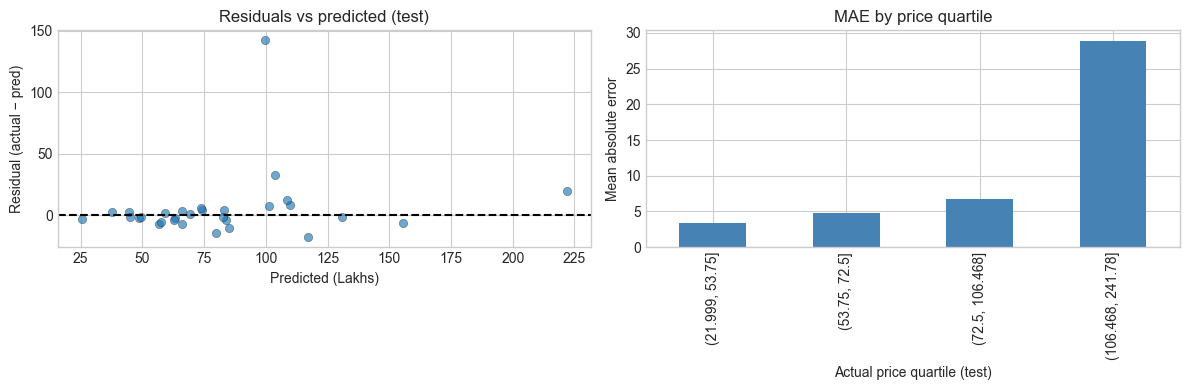

Top 10 worst predictions (test) — inspect tail / luxury / thin geo:


,Actual,Predicted,Abs err,Sub-Area,BHK,Area sqft,amenity_score
0,241.78,99.55,142.23,Pisoli,3,923.0,4
1,136.00,103.66,32.34,Koregoan,3,1060.0,3
2,241.78,221.95,19.83,Baner,4,1740.0,2
3,98.87,117.00,18.13,Hinjewadi,3,980.0,4
4,65.00,79.69,14.69,Ravet,2,905.0,4
5,121.00,108.73,12.27,Karvanagar,2,805.0,2
6,75.00,85.22,10.22,Balewadi,2,894.5,4
7,118.00,109.73,8.27,Vimannagar,2,904.0,4
8,109.00,101.32,7.68,Manjri,3,1073.5,4
9,59.00,66.16,7.16,Manjri,2,731.5,4


Top 12 features (model-native importance):


,importance
area_x_bhk,0.349125
te_township,0.298399
log_area,0.124867
Property Area in Sq. Ft.,0.089140
train_median_ppsf_subarea,0.082306
bhk_count,0.033324
amenity_x_area,0.006618
desc_length,0.003913
te_subarea,0.003523
Total TownShip Area in Acres,0.003012


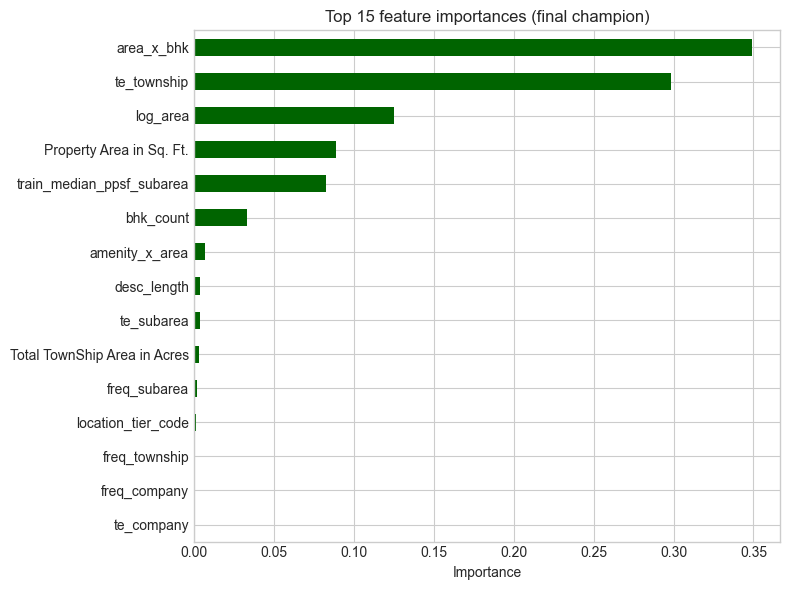

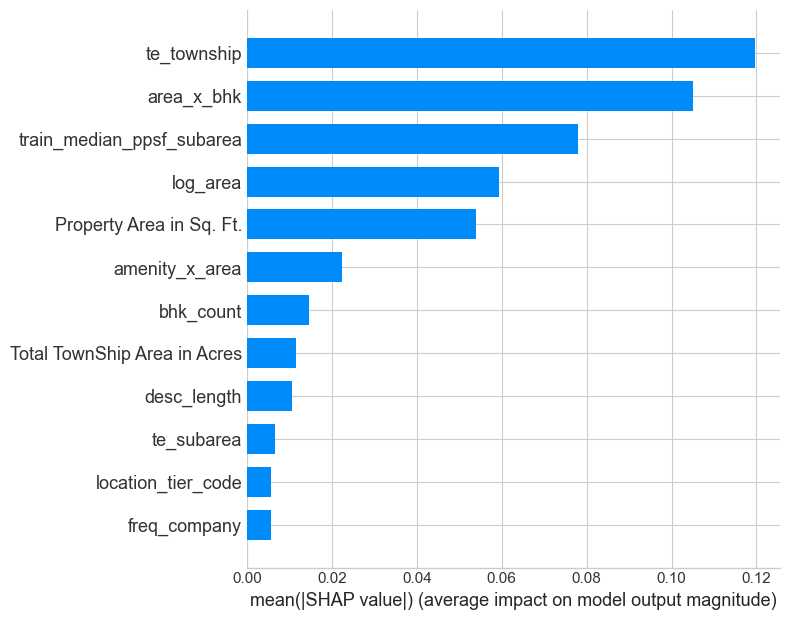

In [28]:
# Error analysis, feature importance, optional SHAP (tree models only).

# --- MAE by price tier (low / mid / high) on TEST using tertiles of actual price
df_err = pd.DataFrame({'actual': actual_price, 'pred': predicted_price, 'abs_err': abs_error})
tiers = pd.qcut(df_err['actual'], q=3, labels=['low', 'mid', 'high'], duplicates='drop')
mae_by_tier = df_err.groupby(tiers, observed=True)['abs_err'].apply(lambda s: s.mean())
mae_by_tier.name = 'MAE (Lakhs)'
print('MAE by actual-price tier (test tertiles):')
display(mae_by_tier.to_frame().round(3))

# Pattern: high tier often dominates MAE on small samples when luxury is underfit.
resid = actual_price - predicted_price

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(predicted_price, resid, alpha=0.65, edgecolor='k', linewidth=0.3)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_xlabel('Predicted (Lakhs)')
axes[0].set_ylabel('Residual (actual − pred)')
axes[0].set_title('Residuals vs predicted (test)')

df_e = pd.DataFrame({'act': actual_price, 'ae': np.abs(resid)})
df_e['bucket'] = pd.qcut(df_e['act'], q=4, duplicates='drop')
df_e.groupby('bucket', observed=True)['ae'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_xlabel('Actual price quartile (test)')
axes[1].set_ylabel('Mean absolute error')
axes[1].set_title('MAE by price quartile')
plt.tight_layout()
plt.show()

# --- Top 10 worst absolute errors + key features (interpretability for failures)
meta = df.iloc[test_idx].reset_index(drop=True)
worst_idx = np.argsort(abs_error)[::-1][:10]
worst_tbl = pd.DataFrame({
    'Actual': actual_price[worst_idx],
    'Predicted': predicted_price[worst_idx],
    'Abs err': abs_error[worst_idx],
    'Sub-Area': meta['Sub-Area'].iloc[worst_idx].values,
    'BHK': meta['bhk_count'].iloc[worst_idx].values,
    'Area sqft': meta['Property Area in Sq. Ft.'].iloc[worst_idx].values,
    'amenity_score': meta['amenity_score'].iloc[worst_idx].values,
})
print('Top 10 worst predictions (test) — inspect tail / luxury / thin geo:')
display(worst_tbl.round(2))

# --- Feature importances (GB / CatBoost): native split-based importance
if best_name == 'GradientBoosting':
    imp = pd.Series(final_model.feature_importances_, index=Xn_trv.columns).sort_values(ascending=False)
elif best_name == 'CatBoost':
    imp = pd.Series(final_model.get_feature_importance(), index=X_trv.columns).sort_values(ascending=False)
else:
    imp = None

if imp is not None:
    print('Top 12 features (model-native importance):')
    display(imp.head(12).to_frame('importance'))
    imp.nlargest(15).sort_values().plot(kind='barh', figsize=(8, 6), color='darkgreen')
    plt.title('Top 15 feature importances (final champion)')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    # Drivers called out in take-homes: area (log_area, area_x_bhk), location encodings, BHK, amenities
else:
    print('Champion is linear: importances not shown — use coefficients or permutation importance if needed.')

# --- Optional SHAP (fast for ~170 train rows + tree model)
if best_name in ('GradientBoosting', 'CatBoost'):
    try:
        import shap
        if best_name == 'GradientBoosting':
            bg = Xn_trv.sample(min(128, len(Xn_trv)), random_state=42)
            explainer = shap.TreeExplainer(final_model, data=bg)
            X_exp = X_test[numeric_features].iloc[: min(64, len(X_test))]
            sv = explainer.shap_values(X_exp)
            shap.summary_plot(sv, X_exp, plot_type='bar', max_display=12, show=True)
        else:
            bg = X_trv.sample(min(128, len(X_trv)), random_state=42)
            explainer = shap.TreeExplainer(final_model, data=bg)
            X_exp = X_test.iloc[: min(64, len(X_test))]
            sv = explainer.shap_values(X_exp)
            shap.summary_plot(sv, X_exp, plot_type='bar', max_display=12, show=True)
    except Exception as e:
        print('SHAP skipped (install with pip install shap if you want this plot):', e)



### Error analysis — how to read the worst cases

- **Rising MAE in high-price tiers** usually means **heteroscedasticity** (lakhs of error scale with price) and **thin tail data** — not necessarily a bug in mid-market fit.
- **Largest errors** often combine **big area / high BHK** with **micro-markets** where the train prior is weak; the model shrinks toward the **typical** unit and under/over-shoots premia not in the feature vector.
- **`price_label` here** compares **realized listing price** to the **calibrated band** (assignment rubric). It tags **band violations for QA**, not independent appraisal of "mislisted" asks.


## 8. Alternative uncertainty — quantile GB

**Why:** compare a direct quantile model to **residual calibration**; on small `n`, tail coverage often favors the latter.


In [29]:
# Alternative intervals: quantile GB on numeric features + symmetric σ bands (illustrative).
# Primary product bands: lower_bound / upper_bound from val residual quantiles (previous section).

num_X_trv = X_trv[numeric_features].values
num_X_test = X_test[numeric_features].values
y_trv_l = np.expm1(y_trv.values)

q_lo_m = GradientBoostingRegressor(
    loss='quantile', alpha=0.1, random_state=42,
    max_depth=5, n_estimators=500, learning_rate=0.03,
)
q_hi_m = GradientBoostingRegressor(
    loss='quantile', alpha=0.9, random_state=42,
    max_depth=5, n_estimators=500, learning_rate=0.03,
)
q_lo_m.fit(num_X_trv, y_trv_l)
q_hi_m.fit(num_X_trv, y_trv_l)
lo_q = np.maximum(0, q_lo_m.predict(num_X_test))
hi_q = np.maximum(q_hi_m.predict(num_X_test), predicted_price)
inside_q = (actual_price >= lo_q) & (actual_price <= hi_q)
print('Quantile GB (10–90, Lakhs direct) — test coverage:', round(100 * inside_q.mean(), 1), '%')

inside_sym = (actual_price >= lower_bound_sym) & (actual_price <= upper_bound_sym)
print(f'Symmetric ±{k}σ (val residual std) — test coverage:', round(100 * inside_sym.mean(), 1), '%')

compare_top = pd.DataFrame({
    'Actual': np.round(actual_price, 1),
    'Predicted': np.round(predicted_price, 1),
    'Lower_cal': np.round(lower_bound, 1),
    'Upper_cal': np.round(upper_bound, 1),
    'Q10': np.round(lo_q, 1),
    'Q90': np.round(hi_q, 1),
}).iloc[np.argsort(abs_error)[::-1][:10]]
display(compare_top)



Quantile GB (10–90, Lakhs direct) — test coverage: 53.3 %
Symmetric ±1.96σ (val residual std) — test coverage: 96.7 %


,Actual,Predicted,Lower_cal,Upper_cal,Q10,Q90
10,241.8,99.5,84.9,123.0,60.0,144.5
2,136.0,103.7,89.0,127.1,82.8,114.1
13,241.8,222.0,207.3,245.4,135.1,222.0
28,98.9,117.0,102.3,140.4,95.6,117.0
7,65.0,79.7,65.0,103.1,74.2,85.6
27,121.0,108.7,94.0,132.1,75.5,118.1
9,75.0,85.2,70.5,108.6,80.1,88.4
26,118.0,109.7,95.0,133.1,83.9,111.2
22,109.0,101.3,86.6,124.7,82.2,120.6
0,59.0,66.2,51.5,89.6,61.4,95.6


### Overall idea

The goal of this assignment was to solve a real problem where similar properties are listed at very different prices, which reduces trust on the platform :contentReference[oaicite:0]{index=0}. Instead of just predicting a single price, I tried to build something more useful. The model gives a predicted value along with a range, and then compares that with the actual listing price to understand if it looks normal or unusual. The main idea is not to say what the exact price should be, but to give a reasonable estimate and highlight cases that need attention.

### How the system behaves

For each listing, the model outputs a price and a range based on how much it was off during validation. Then I compare the actual price with this range. If it falls inside, it’s treated as normal. If it’s slightly outside, I don’t take strict action, just a small nudge. If it’s clearly outside, it gets flagged for review instead of doing anything automatic. I also look at how confident the model is. If the range is too wide, especially for high-price properties, I avoid automation completely and send it for manual checking. This way, we don’t make risky decisions based only on the model.

### Limitations and what I would do next

There are some clear limitations. The dataset is small, around 200 rows, so results can change depending on the split. The model also struggles more with luxury properties and areas with less data. Because of this, I wouldn’t use it for strict automated decisions yet. A better approach is to first use it internally, then for seller guidance, and only later think about broader usage. If I had more time, I would focus on getting more data, improving location signals, and handling high-price properties separately. The main takeaway for me is that the value comes from combining prediction, uncertainty, and decision logic, not just the model itself.